# Assignment 3: Linear Models

In [42]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
   - What makes a model linear is when its output is directly proportional to its input, creating a straight line. It is linear in its parameters and constant rate of change.
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
   - You interpret the coefficient as the average difference in the outcome between that category and the "baseline" category. It is a shift in intercept.
3. Can linear regression be used for classification? Explain why, or why not.
   - Yes it is possible, but will produce unreliable results and poor probabilities.
4. What are signs that your linear model is over-fitting?
   - If there is very low error on the training data but a high error on the test data.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
   - Multicollinearity is when the independent variables are too correlated with each other. In a two-stage least squares technique, if the instruments are too similar then the first-stage regression fails to properly identify the unique variation, and on the second stage the model can't distinguish their correctly correlated values. 
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
   - You can take the log of those variables or add polynomial terms. This allows the model to bend to fit the data while still technically being a linear regression.
7. What is the interpretation of the slope coefficient in a linear regression?
   - The slope reprisesents the expected change in the outcome ($y$) for every one-unit increase in $x$.
8. Compare the train/test split and $k$-fold cross validation.
   - A train/test split provides a quick one-time evaluation, while k-fold cross validation repeats the process multiple times to provide a more reliable/strong estimate of the model.
9.  How is the $k$ in $k$-fold cross validation typically selected?
    - It is typically selected by using a norm, using either k=5 or k=10.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [19]:
df = pd.read_csv('./data/Q1_clean.csv')
df.columns = df.columns.str.strip()
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [21]:
print('2.1')
avg = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
avg

2.1


,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhatten tends to be the most expensive neighborhood.

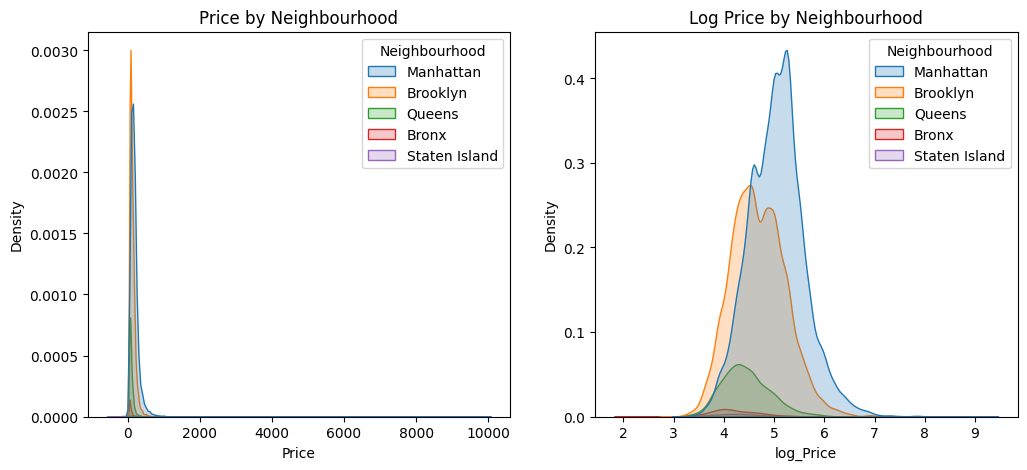

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', fill=True)
plt.title("Price by Neighbourhood")

plt.subplot(1, 2, 2)
df['log_Price'] = np.log(df['Price'])
sns.kdeplot(data=df, x='log_Price', hue='Neighbourhood', fill=True)
plt.title("Log Price by Neighbourhood")
plt.show()

In [24]:
print('2.2')

with_int = smf.ols('Price ~ Neighbourhood', data=df).fit()
print("\nRegression Coefficients (With Intercept):")
print(with_int.params)

2.2

Regression Coefficients (With Intercept):
Intercept                          75.276498
Neighbourhood[T.Brooklyn]          52.470881
Neighbourhood[T.Manhattan]        108.387789
Neighbourhood[T.Queens]            21.580735
Neighbourhood[T.Staten Island]     70.890169
dtype: float64


I dropped the first category, which means I kept the intercept of the regression. The coefficients in the regression are much smaller than the ones in the table from part 1. For example, the regression coefficient of Manhatten in roughly 108 while the coefficient from the table is roughly 183. Bronx is dropped from the regression because its mean price is the intercept (75, which is also the difference between the table and the coefficent regression). 

In [25]:
print('2.3')

price_regress = smf.ols('Price ~ Q("Review Scores Rating")', data=df).fit()
print(price_regress.summary())

2.3
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        14:32:24   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept         

The slope coefficieint of 1.0208 means that for every one unit increase in Review Scores Rating, the predicted price of a listing is expected to increase by roughly $1.02.

In [26]:
print('2.4')

both_regress = smf.ols('Price ~ Neighbourhood + Q("Review Scores Rating")', data=df).fit()
print(both_regress.summary())

2.4
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        14:39:37   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercep

The slope coefficient for Review Scores Rating increased slightly from 1.02 to 1.08, meaning that the higher rating, the more value. The neighborhood numbers represent the "base price" for each area, separating the cost of the location from the cost of the quality.

In [27]:
print('2.5')

part5 = smf.ols('Price ~ 1 + Neighbourhood:Q("Review Scores Rating")', data=df).fit()
print(part5.summary())


2.5
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        14:58:12   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

The slopes are not similar across neighborhoods, since Manhattan’s slope is significantly steeper (about 1.40) than the Bronx (about 0.22) because the model uses the rating to account for the large differences in "base price" between the boroughs.

In [29]:
print('2.6')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Part 3 (Rating Only)": 'Price ~ Q("Review Scores Rating")',
    "Part 4 (Neighbourhood + Rating)": 'Price ~ Neighbourhood + Q("Review Scores Rating")',
    "Part 5 (Separate Slopes/Interactions)": 'Price ~ 1 + Neighbourhood:Q("Review Scores Rating")'
}

for name, formula in models.items():
    rmse_scores = []
    
    for train_idx, test_idx in kf.split(df):
        train, test = df.iloc[train_idx], df.iloc[test_idx]
        
        model = smf.ols(formula, data=train).fit()
        
        predictions = model.predict(test)
        
        rmse = np.sqrt(mean_squared_error(test['Price'], predictions))
        rmse_scores.append(rmse)
    
    print(f"{name} Average RMSE: {np.mean(rmse_scores):.2f}")

2.6
Part 3 (Rating Only) Average RMSE: 144.17
Part 4 (Neighbourhood + Rating) Average RMSE: 140.52
Part 5 (Separate Slopes/Interactions) Average RMSE: 140.43


The best model is the one with the lowest average RMSE (model 5), even though it is very similar to model 4.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [39]:
print('3.1')

df = pd.read_csv('./data/cars_hw.csv')
df.head()

3.1


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0

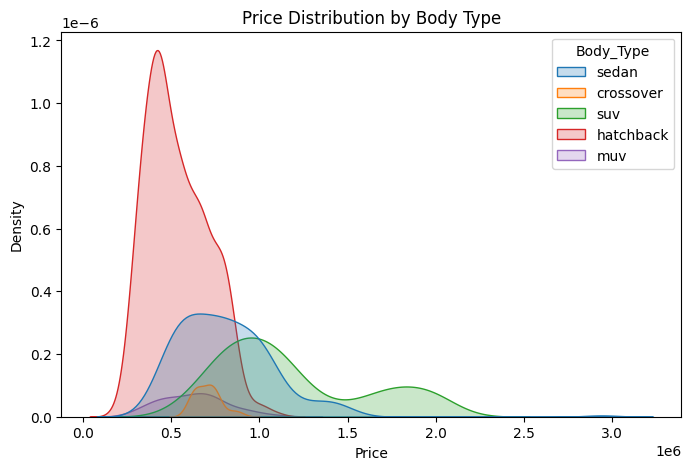

In [40]:
print(df['Price'].describe())

body_stats = df.groupby('Body_Type')['Price'].describe()
print(body_stats)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Price', hue='Body_Type', fill=True)
plt.title("Price Distribution by Body Type")
plt.show()

The most expensive car types are suvs and the ones with the most variance are suvs.

In [41]:
print('3.2')

model_linear = smf.ols('Price ~ Seating_Capacity', data=df).fit()
print("--- Linear Model ---")
print(model_linear.params)

model_cat = smf.ols('Price ~ C(Seating_Capacity)', data=df).fit()
print("\n--- Categorical Model ---")
print(model_cat.params)

3.2
--- Linear Model ---
Intercept           439032.014102
Seating_Capacity     59267.998037
dtype: float64

--- Categorical Model ---
Intercept                   1.880000e+05
C(Seating_Capacity)[T.5]    5.464839e+05
C(Seating_Capacity)[T.6]    1.456000e+06
C(Seating_Capacity)[T.7]    7.359487e+05
C(Seating_Capacity)[T.8]    2.718000e+05
dtype: float64


The slope of 59,268 shows that for every one extra seat in seating capacity, the predicted car price increases by around 59,268 rupees. The price is not linear, due to factors such as how 8-seaters are actually cheaper than 7-seaters.

In [44]:
print('3.3')

df['Age'] = 2026 - df['Make_Year']

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []

for degree in range(1, 7):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(df[['Age']])
    y = df['Price']
    
    model = LinearRegression()
    mse_scores = -cross_val_score(model, X_poly, y, cv=kf, scoring='neg_mean_squared_error')
    
    avg_rmse = np.sqrt(np.mean(mse_scores))
    cv_scores.append(avg_rmse)
    print(f"Degree {degree} RMSE: {avg_rmse:.2f}")

optimal_degree = np.argmin(cv_scores) + 1
print(f"\nThe optimal number of powers for Age is: {optimal_degree}")

3.3
Degree 1 RMSE: 312053.28
Degree 2 RMSE: 312082.85
Degree 3 RMSE: 311035.70
Degree 4 RMSE: 310201.61
Degree 5 RMSE: 308650.35
Degree 6 RMSE: 308802.46

The optimal number of powers for Age is: 5


3.4


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


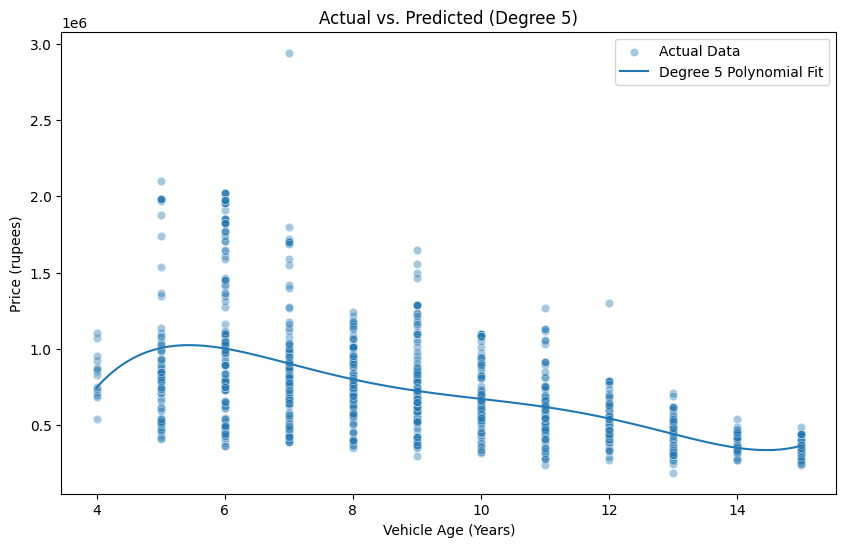

In [48]:
print('3.4')

poly = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_poly = poly.fit_transform(df[['Age']])
model = LinearRegression().fit(X_poly, df['Price'])

age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100).reshape(-1, 1)
age_range_poly = poly.transform(age_range)
price_predictions = model.predict(age_range_poly)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Price', alpha=0.4, label='Actual Data')
plt.plot(age_range, price_predictions, label=f'Degree {optimal_degree} Polynomial Fit')

plt.title(f'Actual vs. Predicted (Degree 5)')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Price (rupees)')
plt.legend()
plt.show()

The model follows the downward trend, but seems to be overfitting.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [49]:
df = pd.read_csv('./data/heart_hw.csv')
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [51]:
print('4.1')

prop_control = df[df['transplant'] == 'control']['y'].mean()
prop_treatment = df[df['transplant'] == 'treatment']['y'].mean()

ate = prop_treatment - prop_control

print(f"Proportion survive (control): {prop_control:.3f}")
print(f"Proportion survive (treatment): {prop_treatment:.3f}")
print(f"ATE on 3 year survival: {ate:.3f}")

4.1
Proportion survive (control): 0.118
Proportion survive (treatment): 0.348
ATE on 3 year survival: 0.230


In [52]:
print('4.2')

model = smf.ols(formula='y ~ transplant', data=df).fit()
print(model.summary())

intercept = model.params['Intercept']
slope = model.params['transplant[T.treatment]']

print(f"\nRegression Intercept: {intercept:.3f}")
print(f"Transplant Coefficient: {slope:.3f}")

4.2
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        16:10:08   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept             

The intercept is equal mean of the baseline group, and the transplant coefficient is the difference between the groups.

4.3
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        16:14:51   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept             

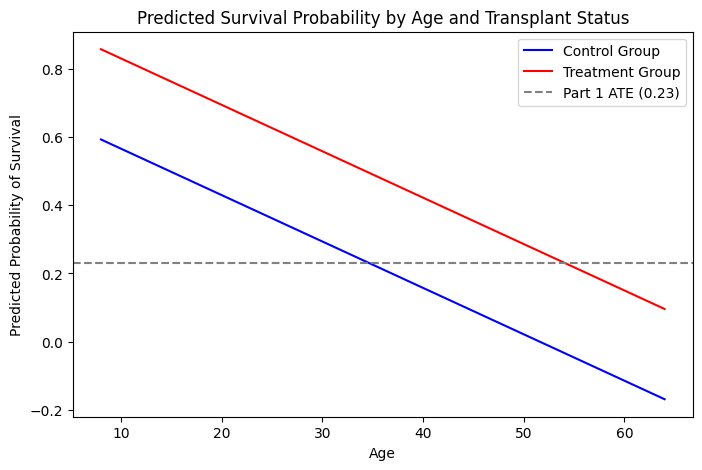

New Transplant Coefficient (controlled for age): 0.265


In [54]:
print('4.3')

model = smf.ols(formula='y ~ transplant + age', data=df).fit()
print(model.summary())

intercept = model.params['Intercept']
coeff_transplant = model.params['transplant[T.treatment]']
coeff_age = model.params['age']
ate_part1 = 0.230  

plt.figure(figsize=(8, 5))

age_range = np.linspace(df['age'].min(), df['age'].max(), 100)

pred_control = intercept + coeff_age * age_range
pred_treatment = (intercept + coeff_transplant) + coeff_age * age_range

plt.plot(age_range, pred_control, label='Control Group', color='blue')
plt.plot(age_range, pred_treatment, label='Treatment Group', color='red')

plt.axhline(y=ate_part1, color='gray', linestyle='--', label=f'Part 1 ATE ({ate_part1})')

plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.title('Predicted Survival Probability by Age and Transplant Status')
plt.legend()
plt.show()

print(f"New Transplant Coefficient (controlled for age): {coeff_transplant:.3f}")

Controlling for age causes the transplant coefficient to increase because the model stops miscounting the survival benefits of being younger as benefits of the surgery itself. This suggests that because age has a negative impact on survival, the ATE was  underestimating the transplant’s effectiveness because it wasn't accounting for the age of the patients.

4.4


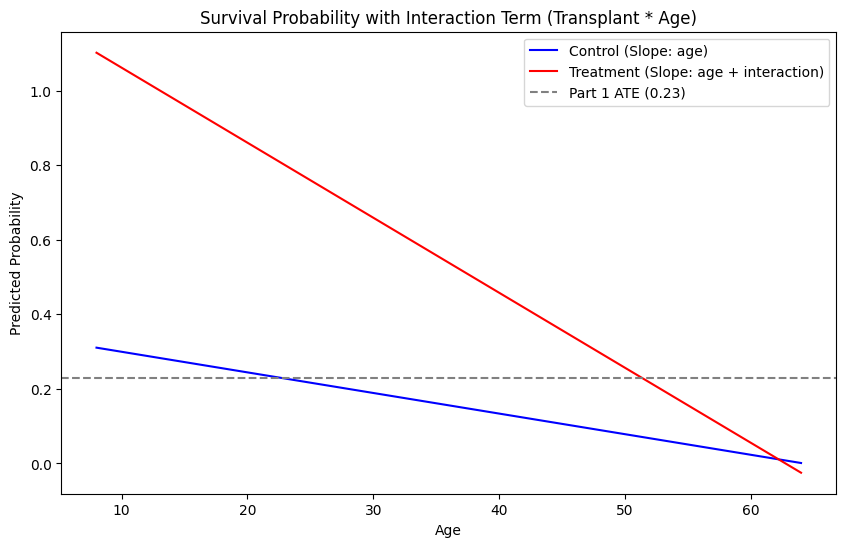

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        13:26:59   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [57]:
print('4.4')

model_int = smf.ols(formula='y ~ transplant * age', data=df).fit()

age_range = np.linspace(df['age'].min(), df['age'].max(), 100)
pred_control = model_int.params['Intercept'] + model_int.params['age'] * age_range
pred_treatment = (model_int.params['Intercept'] + model_int.params['transplant[T.treatment]']) + \
                 (model_int.params['age'] + model_int.params['transplant[T.treatment]:age']) * age_range

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control, label='Control (Slope: age)', color='blue')
plt.plot(age_range, pred_treatment, label='Treatment (Slope: age + interaction)', color='red')
plt.axhline(y=0.230, color='gray', linestyle='--', label='Part 1 ATE (0.23)')
plt.title('Survival Probability with Interaction Term (Transplant * Age)')
plt.xlabel('Age')
plt.ylabel('Predicted Probability')
plt.legend()
plt.show()

print(model_int.summary())

Allowing age and transplant to interact changes the survival gaps between groups depending on age. The lines are no longer parallel, meaning that the transplant is most effective fro younger patients and provides smaller benefit as age increases. 

In [56]:
print('4.5')

df['transplant_numeric'] = df['transplant'].map({'control': 0, 'treatment': 1})
df['interaction'] = df['transplant_numeric'] * df['age']

y = df['y']

features_m1 = df[['transplant_numeric']]
features_m2 = df[['transplant_numeric', 'age']]
features_m3 = df[['transplant_numeric', 'age', 'interaction']]

lr = LinearRegression()

def get_cv_mse(X, y):
    scores = cross_val_score(lr, X, y, cv=10, scoring='neg_mean_squared_error')
    return -np.mean(scores)

mse1 = get_cv_mse(features_m1, y)
mse2 = get_cv_mse(features_m2, y)
mse3 = get_cv_mse(features_m3, y)

print(f"Model 1 (Transplant only) MSE: {mse1:.4f}")
print(f"Model 2 (Transplant + Age) MSE: {mse2:.4f}")
print(f"Model 3 (Transplant * Age) MSE: {mse3:.4f}")

4.5
Model 1 (Transplant only) MSE: 0.2097
Model 2 (Transplant + Age) MSE: 0.1992
Model 3 (Transplant * Age) MSE: 0.1961


4.6 

Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

Relying on a model with only a few variables may ignore key medical context, leading to inaccurate survival predictions that could cost lives. The deployment of this model could jeopardize marginalized groups to be denied care based on biased historical data.